In [1]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

# ✅ Correct path — screenshot lo kanipinchindi
input_path = '/kaggle/input/datasets/equinxx/stock-tweets-for-sentiment-analysis-and-prediction/'

# Load both files
df_tweets = pd.read_csv(input_path + 'stock_tweets.csv')
df_price  = pd.read_csv(input_path + 'stock_yfinance_data.csv')

print("=== TWEETS ===")
print("Shape:", df_tweets.shape)
print(df_tweets.head(3))
print("\nColumns:", df_tweets.columns.tolist())

print("\n=== PRICE ===")
print("Shape:", df_price.shape)
print(df_price.head(3))
print("\nColumns:", df_price.columns.tolist())

=== TWEETS ===
Shape: (80793, 4)
                        Date  \
0  2022-09-29 23:41:16+00:00   
1  2022-09-29 23:24:43+00:00   
2  2022-09-29 23:18:08+00:00   

                                               Tweet Stock Name Company Name  
0  Mainstream media has done an amazing job at br...       TSLA  Tesla, Inc.  
1  Tesla delivery estimates are at around 364k fr...       TSLA  Tesla, Inc.  
2  3/ Even if I include 63.0M unvested RSUs as of...       TSLA  Tesla, Inc.  

Columns: ['Date', 'Tweet', 'Stock Name', 'Company Name']

=== PRICE ===
Shape: (6300, 8)
         Date        Open        High         Low       Close   Adj Close  \
0  2021-09-30  260.333344  263.043335  258.333344  258.493347  258.493347   
1  2021-10-01  259.466675  260.260010  254.529999  258.406677  258.406677   
2  2021-10-04  265.500000  268.989990  258.706665  260.510010  260.510010   

     Volume Stock Name  
0  53868000       TSLA  
1  51094200       TSLA  
2  91449900       TSLA  

Columns: ['Date', 'Ope

In [2]:
# Tweets date clean (timezone remove cheyyi)
df_tweets['Date'] = pd.to_datetime(df_tweets['Date'], utc=True).dt.normalize().dt.tz_localize(None)

# Price date clean
df_price['Date'] = pd.to_datetime(df_price['Date']).dt.normalize()

# Weekends drop
df_tweets = df_tweets[df_tweets['Date'].dt.weekday < 5].reset_index(drop=True)
df_price  = df_price[df_price['Date'].dt.weekday < 5].reset_index(drop=True)

print("Tweets date range:", df_tweets['Date'].min(), "to", df_tweets['Date'].max())
print("Price date range: ", df_price['Date'].min(),  "to", df_price['Date'].max())
print("\nTweets after weekend drop:", len(df_tweets))
print("Stocks in tweets:", df_tweets['Stock Name'].unique())
print("Stocks in price: ", df_price['Stock Name'].unique())

Tweets date range: 2021-09-30 00:00:00 to 2022-09-29 00:00:00
Price date range:  2021-09-30 00:00:00 to 2022-09-29 00:00:00

Tweets after weekend drop: 64809
Stocks in tweets: ['TSLA' 'MSFT' 'PG' 'META' 'AMZN' 'GOOG' 'AMD' 'AAPL' 'NFLX' 'TSM' 'KO'
 'F' 'COST' 'DIS' 'VZ' 'CRM' 'INTC' 'BA' 'BX' 'NOC' 'PYPL' 'ENPH' 'NIO'
 'ZS' 'XPEV']
Stocks in price:  ['TSLA' 'MSFT' 'PG' 'META' 'AMZN' 'GOOG' 'AMD' 'AAPL' 'NFLX' 'TSM' 'KO'
 'F' 'COST' 'DIS' 'VZ' 'CRM' 'INTC' 'BA' 'BX' 'NOC' 'PYPL' 'ENPH' 'NIO'
 'ZS' 'XPEV']


In [3]:
def clean_tweet(text):
    text = str(text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^\w\s$.]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_tweets['clean_tweet'] = df_tweets['Tweet'].apply(clean_tweet)
df_tweets = df_tweets[df_tweets['clean_tweet'].str.len() > 10].reset_index(drop=True)

print(f"Tweets after cleaning: {len(df_tweets)}")
print(df_tweets[['Tweet', 'clean_tweet']].head(3))

Tweets after cleaning: 64217
                                               Tweet  \
0  Mainstream media has done an amazing job at br...   
1  Tesla delivery estimates are at around 364k fr...   
2  3/ Even if I include 63.0M unvested RSUs as of...   

                                         clean_tweet  
0  Mainstream media has done an amazing job at br...  
1  Tesla delivery estimates are at around 364k fr...  
2  3 Even if I include 63.0M unvested RSUs as of ...  


In [4]:
from transformers import pipeline
import torch

device = 0 if torch.cuda.is_available() else -1
print(f"Device: {'GPU ' if device == 0 else 'CPU ⚠️ — Settings lo GPU enable cheyyi!'}")

print("Loading FinBERT...")
finbert = pipeline(
    task       = "sentiment-analysis",
    model      = "ProsusAI/finbert",
    device     = device,
    truncation = True,
    max_length = 512
)
print("FinBERT ready! ")

Device: GPU 
Loading FinBERT...


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

FinBERT ready! 


In [5]:
def get_sentiment_batch(texts, batch_size=64):
    results = []
    total   = len(texts)
    for i in range(0, total, batch_size):
        batch = texts[i : i + batch_size]
        try:
            preds = finbert(batch)
            results.extend(preds)
        except:
            for t in batch:
                try:
                    results.append(finbert(t[:400])[0])
                except:
                    results.append({'label': 'neutral', 'score': 0.5})
        if i % 8000 == 0:
            print(f"  {i}/{total} done ({100*i//total}%)")
    return results

print("Running FinBERT on all tweets... (~20 mins on GPU)")
sentiments = get_sentiment_batch(df_tweets['clean_tweet'].tolist())

df_tweets['sentiment_label'] = [s['label'] for s in sentiments]
df_tweets['sentiment_score'] = [s['score']  for s in sentiments]
df_tweets['sentiment_num']   = df_tweets['sentiment_label'].map(
    {'positive': 1, 'neutral': 0, 'negative': -1}
)

print("\nSentiment done!")
print(df_tweets['sentiment_label'].value_counts())

Running FinBERT on all tweets... (~20 mins on GPU)
  0/64217 done (0%)


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  8000/64217 done (12%)
  16000/64217 done (24%)
  24000/64217 done (37%)
  32000/64217 done (49%)
  40000/64217 done (62%)
  48000/64217 done (74%)
  56000/64217 done (87%)
  64000/64217 done (99%)

Sentiment done!
sentiment_label
neutral     47431
negative     8505
positive     8281
Name: count, dtype: int64


In [6]:
daily_sent = df_tweets.groupby(['Date', 'Stock Name']).agg(
    sentiment_mean = ('sentiment_num',   'mean'),
    pct_positive   = ('sentiment_num',   lambda x: (x ==  1).mean()),
    pct_negative   = ('sentiment_num',   lambda x: (x == -1).mean()),
    tweet_count    = ('sentiment_num',   'count'),
    avg_confidence = ('sentiment_score', 'mean')
).reset_index()

print("Daily sentiment shape:", daily_sent.shape)
print(daily_sent.head())

Daily sentiment shape: (4310, 7)
        Date Stock Name  sentiment_mean  pct_positive  pct_negative  \
0 2021-09-30       AAPL       -0.142857      0.000000      0.142857   
1 2021-09-30        AMD        0.333333      0.333333      0.000000   
2 2021-09-30       AMZN       -0.200000      0.000000      0.200000   
3 2021-09-30        DIS        0.000000      0.000000      0.000000   
4 2021-09-30       GOOG        0.000000      0.000000      0.000000   

   tweet_count  avg_confidence  
0            7        0.846869  
1            6        0.853963  
2            5        0.848516  
3            1        0.910729  
4            1        0.760279  


In [7]:
df_price = df_price.sort_values(['Stock Name', 'Date']).reset_index(drop=True)

def add_indicators(grp):
    grp = grp.copy()
    grp['daily_return'] = grp['Close'].pct_change()
    grp['ma_5']         = grp['Close'].rolling(5).mean()
    grp['ma_20']        = grp['Close'].rolling(20).mean()
    delta               = grp['Close'].diff()
    gain                = delta.clip(lower=0).rolling(14).mean()
    loss                = (-delta.clip(upper=0)).rolling(14).mean()
    grp['rsi']          = 100 - (100 / (1 + gain / (loss + 1e-8)))
    grp['volatility']   = grp['daily_return'].rolling(5).std()
    grp['target']       = (grp['Close'].shift(-1) > grp['Close']).astype(int)
    return grp

df_price = df_price.groupby('Stock Name', group_keys=False).apply(add_indicators)

merged = pd.merge(df_price, daily_sent, on=['Date', 'Stock Name'], how='inner')
merged = merged.dropna().reset_index(drop=True)

print("Merged shape:", merged.shape)
print(merged.columns.tolist())
merged.to_csv('final_features.csv', index=False)
print("Saved! ")

Merged shape: (3862, 19)
['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Stock Name', 'daily_return', 'ma_5', 'ma_20', 'rsi', 'volatility', 'target', 'sentiment_mean', 'pct_positive', 'pct_negative', 'tweet_count', 'avg_confidence']
Saved! 


In [8]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
import xgboost as xgb

FEATURE_COLS = [
    'daily_return', 'ma_5', 'ma_20', 'rsi', 'volatility',
    'sentiment_mean', 'pct_positive', 'pct_negative',
    'tweet_count', 'avg_confidence'
]

X = merged[FEATURE_COLS].values
y = merged['target'].values

tscv     = TimeSeriesSplit(n_splits=5)
xgb_accs = []

for fold, (tr_idx, te_idx) in enumerate(tscv.split(X)):
    X_tr, X_te = X[tr_idx], X[te_idx]
    y_tr, y_te = y[tr_idx], y[te_idx]

    model = xgb.XGBClassifier(
        n_estimators     = 300,
        max_depth        = 4,
        learning_rate    = 0.05,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        scale_pos_weight = (y_tr==0).sum() / (y_tr==1).sum(),
        eval_metric      = 'logloss',
        random_state     = 42
    )
    model.fit(X_tr, y_tr, verbose=False)

    y_pred = model.predict(X_te)
    acc    = accuracy_score(y_te, y_pred)
    auc    = roc_auc_score(y_te, y_pred)
    xgb_accs.append(acc)
    print(f"Fold {fold+1}: Accuracy={acc:.3f}  AUC={auc:.3f}")

print(f"\nMean Accuracy: {np.mean(xgb_accs):.3f}")
print(classification_report(y_te, y_pred))

Fold 1: Accuracy=0.498  AUC=0.496
Fold 2: Accuracy=0.487  AUC=0.490
Fold 3: Accuracy=0.530  AUC=0.521
Fold 4: Accuracy=0.527  AUC=0.522
Fold 5: Accuracy=0.498  AUC=0.496

Mean Accuracy: 0.508
              precision    recall  f1-score   support

           0       0.53      0.52      0.53       343
           1       0.46      0.47      0.47       300

    accuracy                           0.50       643
   macro avg       0.50      0.50      0.50       643
weighted avg       0.50      0.50      0.50       643



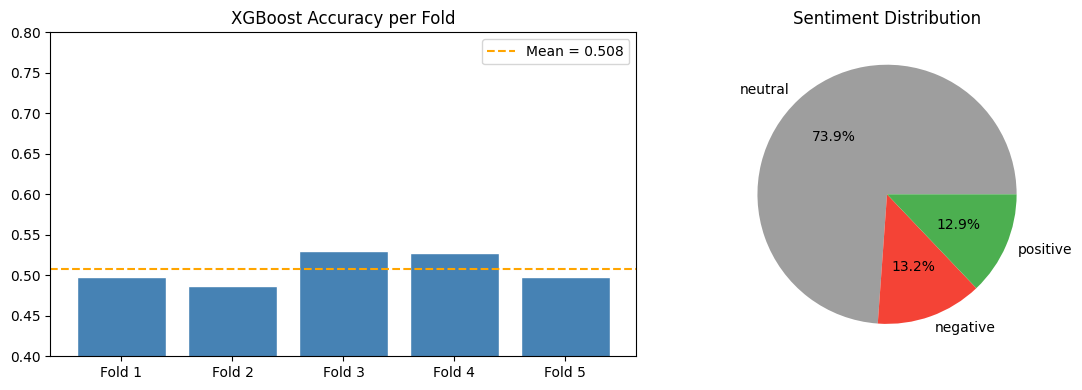

Chart saved! 


In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(
    [f'Fold {i+1}' for i in range(len(xgb_accs))],
    xgb_accs, color='steelblue', edgecolor='white'
)
axes[0].axhline(np.mean(xgb_accs), color='orange',
                linestyle='--', label=f'Mean = {np.mean(xgb_accs):.3f}')
axes[0].set_title('XGBoost Accuracy per Fold')
axes[0].set_ylim(0.4, 0.8)
axes[0].legend()

sent_counts = df_tweets['sentiment_label'].value_counts()
axes[1].pie(
    sent_counts.values,
    labels  = sent_counts.index,
    autopct = '%1.1f%%',
    colors  = ['#9E9E9E', '#F44336', '#4CAF50']
)
axes[1].set_title('Sentiment Distribution')

plt.tight_layout()
plt.savefig('results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved! ")

In [10]:

df_tweets['weighted_sentiment'] = df_tweets['sentiment_num'] * df_tweets['sentiment_score']

# Improved daily aggregation
daily_sent_v2 = df_tweets.groupby(['Date', 'Stock Name']).agg(
    sentiment_mean     = ('sentiment_num',      'mean'),
    weighted_sentiment = ('weighted_sentiment', 'mean'),
    pct_positive       = ('sentiment_num',      lambda x: (x ==  1).mean()),
    pct_negative       = ('sentiment_num',      lambda x: (x == -1).mean()),
    sentiment_std      = ('sentiment_num',      'std'),
    tweet_count        = ('sentiment_num',      'count'),
    avg_confidence     = ('sentiment_score',    'mean'),
    # Bullish ratio — key feature
    bullish_ratio      = ('sentiment_num',      lambda x: (x==1).sum() / max((x==-1).sum(), 1))
).reset_index()

daily_sent_v2['sentiment_std'] = daily_sent_v2['sentiment_std'].fillna(0)

print("Improved sentiment shape:", daily_sent_v2.shape)
print(daily_sent_v2.head())

Improved sentiment shape: (4310, 10)
        Date Stock Name  sentiment_mean  weighted_sentiment  pct_positive  \
0 2021-09-30       AAPL       -0.142857           -0.120790      0.000000   
1 2021-09-30        AMD        0.333333            0.301795      0.333333   
2 2021-09-30       AMZN       -0.200000           -0.169107      0.000000   
3 2021-09-30        DIS        0.000000            0.000000      0.000000   
4 2021-09-30       GOOG        0.000000            0.000000      0.000000   

   pct_negative  sentiment_std  tweet_count  avg_confidence  bullish_ratio  
0      0.142857       0.377964            7        0.846869            0.0  
1      0.000000       0.516398            6        0.853963            2.0  
2      0.200000       0.447214            5        0.848516            0.0  
3      0.000000       0.000000            1        0.910729            0.0  
4      0.000000       0.000000            1        0.760279            0.0  


In [11]:
def add_indicators_v2(grp):
    grp = grp.copy()
    grp['daily_return']  = grp['Close'].pct_change()
    grp['ma_5']          = grp['Close'].rolling(5).mean()
    grp['ma_20']         = grp['Close'].rolling(20).mean()
    grp['ma_50']         = grp['Close'].rolling(50).mean()

    # RSI
    delta = grp['Close'].diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    grp['rsi'] = 100 - (100 / (1 + gain / (loss + 1e-8)))

    # MACD
    ema12 = grp['Close'].ewm(span=12).mean()
    ema26 = grp['Close'].ewm(span=26).mean()
    grp['macd']          = ema12 - ema26
    grp['macd_signal']   = grp['macd'].ewm(span=9).mean()

    # Bollinger Bands
    rolling_std          = grp['Close'].rolling(20).std()
    grp['bb_upper']      = grp['ma_20'] + (2 * rolling_std)
    grp['bb_lower']      = grp['ma_20'] - (2 * rolling_std)
    grp['bb_position']   = (grp['Close'] - grp['bb_lower']) / (grp['bb_upper'] - grp['bb_lower'] + 1e-8)

    # Volume change
    grp['volume_change'] = grp['Volume'].pct_change()

    # Volatility
    grp['volatility']    = grp['daily_return'].rolling(5).std()

    # Lagged returns (yesterday, 2 days ago)
    grp['return_lag1']   = grp['daily_return'].shift(1)
    grp['return_lag2']   = grp['daily_return'].shift(2)

    # Target
    grp['target']        = (grp['Close'].shift(-1) > grp['Close']).astype(int)
    return grp

df_price_v2 = df_price.groupby('Stock Name', group_keys=False).apply(add_indicators_v2)

# Re-merge with improved sentiment
merged_v2 = pd.merge(df_price_v2, daily_sent_v2, on=['Date', 'Stock Name'], how='inner')
merged_v2 = merged_v2.dropna().reset_index(drop=True)

print("Improved merged shape:", merged_v2.shape)
merged_v2.to_csv('final_features_v2.csv', index=False)
print("Saved! v2")

Improved merged shape: (3357, 31)
Saved! v2


Fold 1: Accuracy=0.496  AUC=0.490
Fold 2: Accuracy=0.530  AUC=0.531
Fold 3: Accuracy=0.571  AUC=0.567
Fold 4: Accuracy=0.542  AUC=0.528
Fold 5: Accuracy=0.494  AUC=0.483

Improved Mean Accuracy: 0.526
              precision    recall  f1-score   support

           0       0.53      0.62      0.57       301
           1       0.44      0.35      0.39       258

    accuracy                           0.49       559
   macro avg       0.48      0.48      0.48       559
weighted avg       0.49      0.49      0.49       559


Calculating SHAP values...


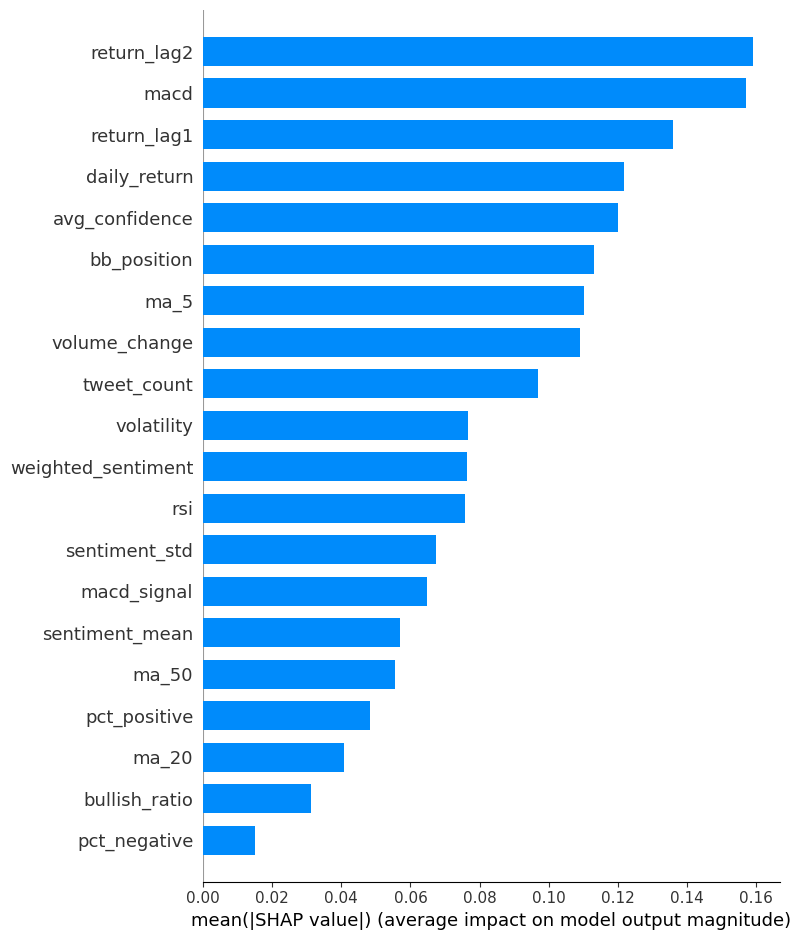

In [12]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
import xgboost as xgb
import shap

FEATURE_COLS_V2 = [
    'daily_return', 'return_lag1', 'return_lag2',
    'ma_5', 'ma_20', 'ma_50',
    'rsi', 'macd', 'macd_signal',
    'bb_position', 'volume_change', 'volatility',
    'sentiment_mean', 'weighted_sentiment',
    'pct_positive', 'pct_negative',
    'sentiment_std', 'tweet_count',
    'avg_confidence', 'bullish_ratio'
]

X2 = merged_v2[FEATURE_COLS_V2].values
y2 = merged_v2['target'].values

tscv      = TimeSeriesSplit(n_splits=5)
xgb_accs2 = []

for fold, (tr_idx, te_idx) in enumerate(tscv.split(X2)):
    X_tr, X_te = X2[tr_idx], X2[te_idx]
    y_tr, y_te = y2[tr_idx], y2[te_idx]

    model_v2 = xgb.XGBClassifier(
        n_estimators     = 500,
        max_depth        = 5,
        learning_rate    = 0.03,
        subsample        = 0.8,
        colsample_bytree = 0.7,
        min_child_weight = 3,
        gamma            = 0.1,
        scale_pos_weight = (y_tr==0).sum() / (y_tr==1).sum(),
        eval_metric      = 'logloss',
        random_state     = 42
    )
    model_v2.fit(X_tr, y_tr, verbose=False)

    y_pred2 = model_v2.predict(X_te)
    acc     = accuracy_score(y_te, y_pred2)
    auc     = roc_auc_score(y_te, y_pred2)
    xgb_accs2.append(acc)
    print(f"Fold {fold+1}: Accuracy={acc:.3f}  AUC={auc:.3f}")

print(f"\nImproved Mean Accuracy: {np.mean(xgb_accs2):.3f}")
print(classification_report(y_te, y_pred2))

# SHAP — which features matter most
print("\nCalculating SHAP values...")
explainer  = shap.TreeExplainer(model_v2)
shap_vals  = explainer.shap_values(X_te)
shap.summary_plot(
    shap_vals, X_te,
    feature_names = FEATURE_COLS_V2,
    plot_type     = "bar",
    show          = True
)

In [15]:
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

def predict_tomorrow(ticker, model_v2, feature_cols, daily_sent_v2):

    try:
        # -----------------------------
        # Fetch latest stock data
        # -----------------------------
        end = datetime.today()
        start = end - timedelta(days=120)

        price = yf.download(
            ticker,
            start=start,
            end=end,
            auto_adjust=True,
            progress=False
        )

        # Check if data exists
        if price.empty:
            print(f"No stock price data found for {ticker}")
            return

        # Reset index
        price = price.reset_index()

        # Handle multi-index columns if present
        price.columns = [
            c[0] if isinstance(c, tuple) else c
            for c in price.columns
        ]

        # Normalize dates
        price['Date'] = pd.to_datetime(price['Date']).dt.normalize()

        # -----------------------------
        # Technical Indicators
        # -----------------------------
        price['daily_return'] = price['Close'].pct_change()

        price['return_lag1'] = price['daily_return'].shift(1)
        price['return_lag2'] = price['daily_return'].shift(2)

        price['ma_5'] = price['Close'].rolling(5).mean()
        price['ma_20'] = price['Close'].rolling(20).mean()
        price['ma_50'] = price['Close'].rolling(50).mean()

        # RSI
        delta = price['Close'].diff()

        gain = delta.clip(lower=0).rolling(14).mean()
        loss = (-delta.clip(upper=0)).rolling(14).mean()

        rs = gain / (loss + 1e-8)

        price['rsi'] = 100 - (100 / (1 + rs))

        # MACD
        ema12 = price['Close'].ewm(span=12).mean()
        ema26 = price['Close'].ewm(span=26).mean()

        price['macd'] = ema12 - ema26
        price['macd_signal'] = price['macd'].ewm(span=9).mean()

        # Bollinger Bands
        rolling_std = price['Close'].rolling(20).std()
        ma20 = price['Close'].rolling(20).mean()

        bb_upper = ma20 + 2 * rolling_std
        bb_lower = ma20 - 2 * rolling_std

        price['bb_position'] = (
            (price['Close'] - bb_lower) /
            (bb_upper - bb_lower + 1e-8)
        )

        # Volume + Volatility
        price['volume_change'] = price['Volume'].pct_change()

        price['volatility'] = (
            price['daily_return'].rolling(5).std()
        )

        # -----------------------------
        # Remove NaN rows safely
        # -----------------------------
        price_clean = price.dropna()

        if price_clean.empty:
            print(f"No sufficient technical indicator data available for {ticker}")
            return

        latest_price = price_clean.iloc[-1]

        # -----------------------------
        # Sentiment Data
        # -----------------------------
        sent_data = daily_sent_v2[
            daily_sent_v2['Stock Name'] == ticker
        ]

        if sent_data.empty:
            print(f"No sentiment data available for {ticker}")
            return

        sent_row = sent_data.iloc[-1]

        # -----------------------------
        # Feature Vector
        # -----------------------------
        features = {
            'daily_return': latest_price['daily_return'],
            'return_lag1': latest_price['return_lag1'],
            'return_lag2': latest_price['return_lag2'],
            'ma_5': latest_price['ma_5'],
            'ma_20': latest_price['ma_20'],
            'ma_50': latest_price['ma_50'],
            'rsi': latest_price['rsi'],
            'macd': latest_price['macd'],
            'macd_signal': latest_price['macd_signal'],
            'bb_position': latest_price['bb_position'],
            'volume_change': latest_price['volume_change'],
            'volatility': latest_price['volatility'],
            'sentiment_mean': sent_row['sentiment_mean'],
            'weighted_sentiment': sent_row['weighted_sentiment'],
            'pct_positive': sent_row['pct_positive'],
            'pct_negative': sent_row['pct_negative'],
            'sentiment_std': sent_row['sentiment_std'],
            'tweet_count': sent_row['tweet_count'],
            'avg_confidence': sent_row['avg_confidence'],
            'bullish_ratio': sent_row['bullish_ratio'],
        }

        # -----------------------------
        # Prepare Input
        # -----------------------------
        X_input = np.array([
            [features[col] for col in feature_cols]
        ])

        # -----------------------------
        # Prediction
        # -----------------------------
        prob = model_v2.predict_proba(X_input)[0]

        pred = model_v2.predict(X_input)[0]

        # -----------------------------
        # Output
        # -----------------------------
        print("\n==============================")
        print(f"Stock       : {ticker}")
        print(f"Current     : ${latest_price['Close']:.2f}")
        print(f"RSI         : {latest_price['rsi']:.2f}")
        print(f"Prediction  : {'UP' if pred == 1 else 'DOWN'}")
        print(f"Confidence  : {max(prob) * 100:.2f}%")
        print(f"UP Prob     : {prob[1] * 100:.2f}%")
        print(f"DOWN Prob   : {prob[0] * 100:.2f}%")
        print("==============================")

    except Exception as e:
        print(f"Error occurred: {e}")


# -----------------------------
# TEST
# -----------------------------
predict_tomorrow(
    'TSLA',
    model_v2,
    FEATURE_COLS_V2,
    daily_sent_v2
)


Stock       : TSLA
Current     : $440.36
RSI         : 64.16
Prediction  : DOWN
Confidence  : 69.66%
UP Prob     : 30.34%
DOWN Prob   : 69.66%
